# Patran and Femap neutral files, and MFEM meshes

Three interchange formats added in v16.5.0:

- **The Patran 2 neutral file (`.pat`, `.out`)** is MSC Patran's legacy interchange, still exported by Cubit, Patran and ANSA and read by Fluent and Feko: fixed-width packets of nodes, elements and named components.
- **The Femap neutral file (`.neu`)** is Femap's documented interchange, and what NX Nastran, MYSTRAN and EMSolution write their results to: comma-separated blocks whose layout changes with the Femap version. meshio++ reads the mesh, property titles, groups and every output set as a step, and writes the mesh.
- **MFEM's `.mesh` and `.gf`** are the curved high-order meshes and solution fields of the [MFEM](https://mfem.org) library, the files GLVis views. meshio++ reads order-2 meshes in MFEM's own degree-of-freedom numbering and the grid functions on them.

The files are in `tests/python/meshes/`: Patran decks written from the Patran documentation, real Femap, EMSolution and MYSTRAN files (MIT), and MFEM's own sample meshes (BSD-3) with fields MFEM projected.

In [1]:
import os
import tempfile

import matplotlib.pyplot as plt
import numpy as np
import pyvista as pv

# Keep the outputs readable: the warnings the readers and writers print are discussed in the text.
os.environ.setdefault('MESHIOPLUSPLUS_LOG_LEVEL', 'error')
import meshioplusplus as mp  # noqa: E402

# Head-less, static rendering (no display / live server needed).
pv.OFF_SCREEN = True
pv.set_jupyter_backend('static')

MESHES = os.path.join(os.path.dirname(os.path.dirname(os.getcwd())), 'tests', 'python', 'meshes')
TMP = tempfile.mkdtemp()


def path(folder, name):
    return os.path.join(MESHES, folder, name)


def region_array(mesh, names=None):
    '''Per-cell index of the cell region holding each cell (NaN for none), as cell_data.'''
    regions = [r for r in mesh.regions if r.kind == 'cell' and (names is None or r.name in names)]
    flat = np.full(sum(len(c.data) for c in mesh.cells), np.nan)
    for k, r in enumerate(regions):
        flat[r.entries] = k
    out, start = [], 0
    for c in mesh.cells:
        out.append(flat[start:start + len(c.data)])
        start += len(c.data)
    return out


def curved(grid, level=3):
    '''The surface of `grid` with its quadratic cells subdivided, so curved edges look curved.'''
    return grid.extract_surface(nonlinear_subdivision=level, algorithm='dataset_surface')


def to_grid(mesh, cell_data=None, point_data=None):
    '''A PyVista grid of `mesh`'s surfaces and solids (through a .vtu, so quadratic cells stay quadratic).'''
    keep = [i for i, c in enumerate(mesh.cells) if c.type not in ('vertex', 'line', 'line3', 'line4')]
    cells = [mesh.cells[i] for i in keep]
    cd = {k: [v[i] for i in keep] for k, v in (cell_data or {}).items()}
    target = os.path.join(TMP, 'render.vtu')
    mp.write(target, mp.Mesh(mesh.points, cells, point_data=point_data or {}, cell_data=cd))
    return pv.read(target)


def gallery(items, ncols=2, size=(760, 460), view=(-1.0, -1.4, 0.45), edges=True):
    '''Render `(grid, scalars, title, clim)` items side by side, or with matplotlib when GL is unavailable.'''
    nrows = -(-len(items) // ncols)
    fig = plt.figure(figsize=(5.6 * ncols, 3.6 * nrows))
    for k, (grid, scalars, title, clim) in enumerate(items, start=1):
        try:
            pl = pv.Plotter(off_screen=True, window_size=size)
            pl.add_mesh(grid, scalars=scalars, cmap='turbo', clim=clim, show_edges=edges, edge_color='#333333',
                        line_width=0.6, nan_color='#bbbbbb',
                        scalar_bar_args={'title': scalars, 'vertical': True, 'position_x': 0.82,
                                         'position_y': 0.12, 'height': 0.76, 'width': 0.08})
            pl.view_vector(view, viewup=(0, 1, 0) if view == (0, 0, 1) else (0, 0, 1))
            pl.reset_camera()
            pl.camera.zoom(1.0)
            img = pl.screenshot(return_img=True)
            pl.close()
            ax = fig.add_subplot(nrows, ncols, k)
            ax.imshow(img)
        except Exception as exc:  # pragma: no cover - head-less GL fallback
            print('PyVista render skipped:', exc)
            ax = fig.add_subplot(nrows, ncols, k, projection='3d')
            p = np.asarray(grid.points)
            ax.scatter(p[:, 0], p[:, 1], p[:, 2], s=8)
        ax.set_title(title, fontsize=10)
        ax.axis('off')
    plt.tight_layout()
    plt.show()

## Patran: packets and components

A Patran file is a sequence of packets, each opened by a fixed-width `(I2,8I8)` header card: packet type, id, shape, card count. `mixed_linear.pat` holds one of each linear solid, two quads and a bar, with gaps in its ids and three named components. The components become point and cell regions; the quads and the bar are in none, so they are grouped by property.

25       0       0       1       0       0       0       0       0
mixed linear fixture for meshio++
26       0       0       1      33       7       1       2       0
23-Sep-26   12:00:00         3.0
 1      10       0       2       0       0       0       0       0
 0.000000000E+00 0.000000000E+00 0.000000000E+00
1G       6       0       0  000000
 1      20       0       2       0       0       0       0       0

<meshio++ mesh object>
  Number of points: 33
  Number of cells:
    hexahedron: 1
    wedge: 1
    tetra: 1
    pyramid: 1
    quad: 2
    line: 1
  Point sets: FIXED, MIXED
  Cell sets: MIXED, SOLIDS, property_2, property_3
  Cell data: patran:property
FIXED       point tag  4: 4 entries
MIXED       point tag  9: 2 entries
MIXED       cell  tag  9: 1 entries
SOLIDS      cell  tag  1: 4 entries
property_2  cell  tag  2: 1 entries
property_3  cell  tag  3: 1 entries


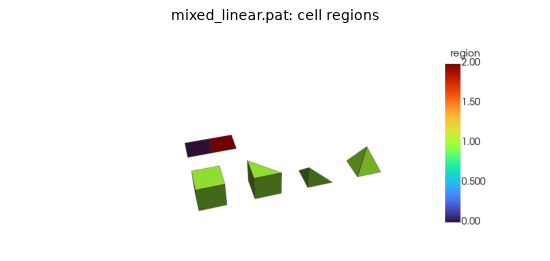

In [2]:
pat = path('patran', 'mixed_linear.pat')
with open(pat) as fh:
    print(''.join(fh.readlines()[:8]))
mixed = mp.read(pat)
print(mixed)
for r in mixed.regions:
    print(f'{r.name:11s} {r.kind:5s} tag {r.tag:2d}: {len(r.entries)} entries')
gallery([(to_grid(mixed, cell_data={'region': region_array(mixed)}), 'region', 'mixed_linear.pat: cell regions', None)],
        ncols=1, size=(1000, 420), view=(-0.3, -1.0, 0.8))

Patran's 20-node hexahedron and 15-node wedge list their mid-edge nodes as the bottom ring, the **vertical** edges, then the top ring; VTK puts the vertical ones last. `quadratic.pat` has one quadratic cell of each shape, written from Patran's own edge lists, and every mid-edge node lands on its edge's midpoint after reading.

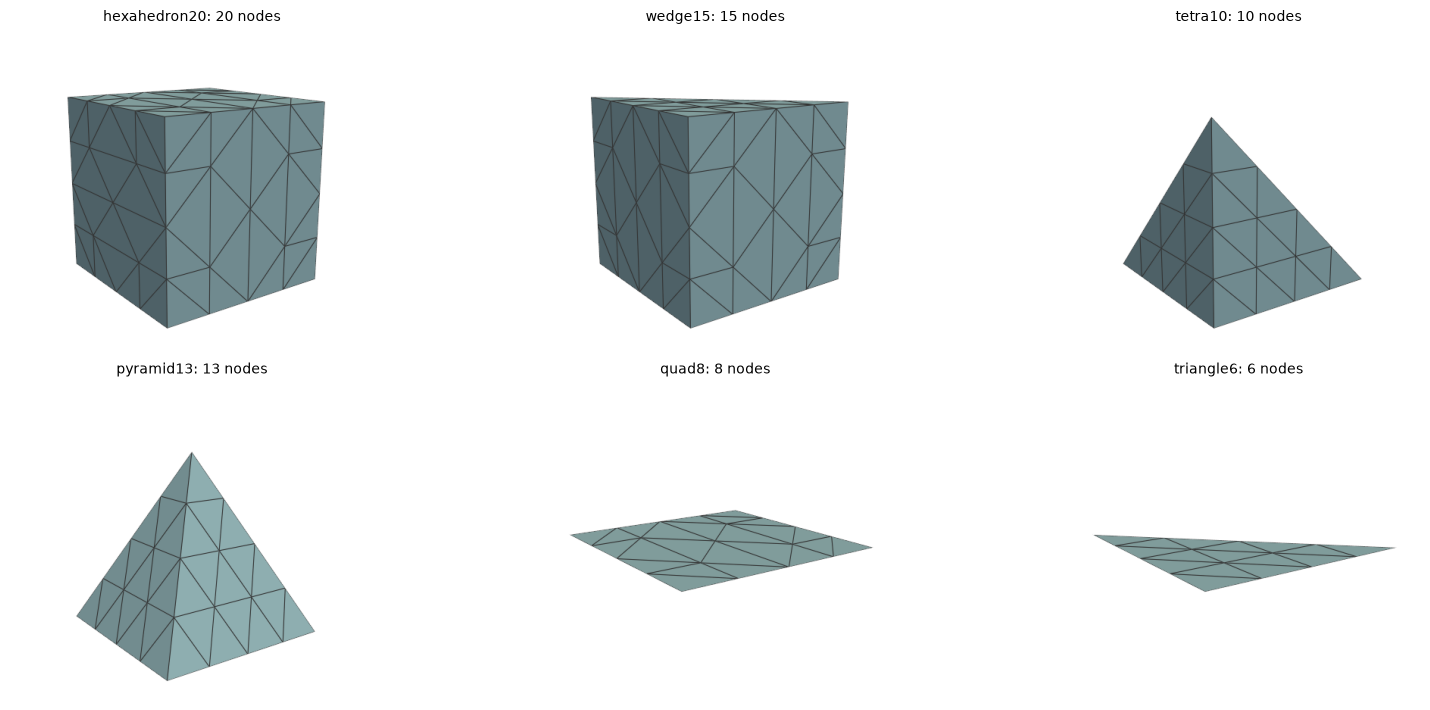

In [3]:
quad = mp.read(path('patran', 'quadratic.pat'))
items = []
for block in quad.cells:
    if block.type == 'line3':
        continue
    row = block.data[0]
    one = mp.Mesh(quad.points[row], [(block.type, np.arange(len(row))[None])])
    items.append((curved(to_grid(one), 2), None, f'{block.type}: {len(row)} nodes', None))
gallery(items, ncols=3, size=(480, 420))

## Femap: a model and its groups

`MC361.neu` is a real Femap 8.2 model (from FrontISTR's examples): 40 bricks with a property named `EALL` and node and element groups. The property title names its cell region; the groups become point and cell regions.

<meshio++ mesh object>
  Number of points: 525
  Number of cells:
    hexahedron: 40
  Point sets: XMAX1 NSET, XMAX2 NSET, XMAX3 NSET, XMIN NSET
  Cell sets: EALL, XMAX ELSET
  Cell data: femap:property, femap:type
XMAX1 NSET  point tag    2: 4 entries
XMAX2 NSET  point tag    3: 4 entries
XMAX3 NSET  point tag    4: 1 entries
XMIN NSET   point tag    1: 9 entries
EALL        cell  tag    1: 40 entries
XMAX ELSET  cell  tag    5: 4 entries


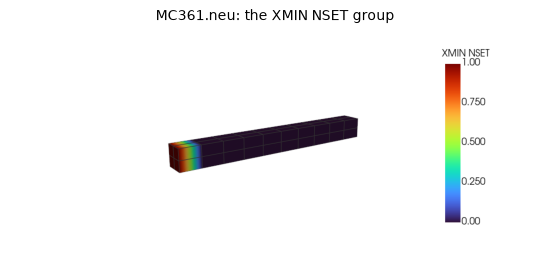

In [4]:
model = mp.read(path('femap', 'MC361.neu'))
print(model)
for r in model.regions:
    print(f'{r.name:11s} {r.kind:5s} tag {r.tag:4d}: {len(r.entries)} entries')
xmin = next(r for r in model.regions if r.name == 'XMIN NSET')
marker = np.zeros(len(model.points))
marker[xmin.entries] = 1
gallery([(to_grid(model, point_data={'XMIN NSET': marker}), 'XMIN NSET', 'MC361.neu: the XMIN NSET group', (0, 1))],
        ncols=1, size=(1000, 420))

Femap stores every element's nodes in 20 slots laid out as a degenerate brick: a tetrahedron's apex sits in slot 4, its mid-edge nodes in the brick's mid-edge slots. The three quadratic FrontISTR models read to valid tetra10, wedge15 and hexahedron20 cells.

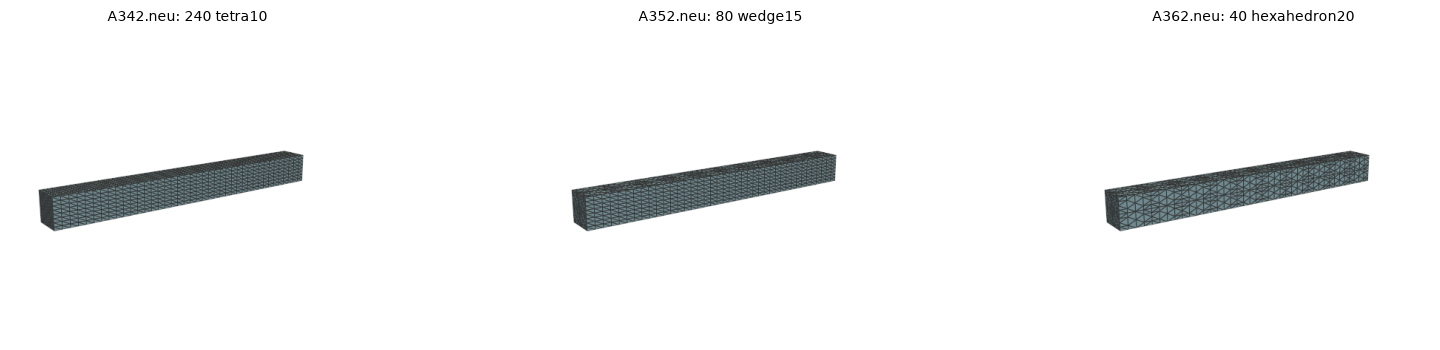

In [5]:
items = []
for name in ('A342', 'A352', 'A362'):
    m = mp.read(path('femap', f'{name}.neu'))
    items.append((curved(to_grid(m), 2), None,
                  f'{name}.neu: {len(m.cells[0].data)} {m.cells[0].type}', None))
gallery(items, ncols=3, size=(480, 420))

## Femap: output sets as steps

EMSolution wrote 13 output sets on a small mixed mesh (tetrahedra, pyramids, wedges and a brick), once as `451` records and once as `1051` ranges. Every output set is a step: `time_step` picks one, its value is `field_data["meshio:time"]`, and its output vectors are point and cell data. Both encodings read to the same arrays.

output set values: [0.      0.00167 0.00333 0.005   0.00667 0.00833 0.01    0.01167 0.01333
 0.015   0.01667 0.01833 0.02   ]


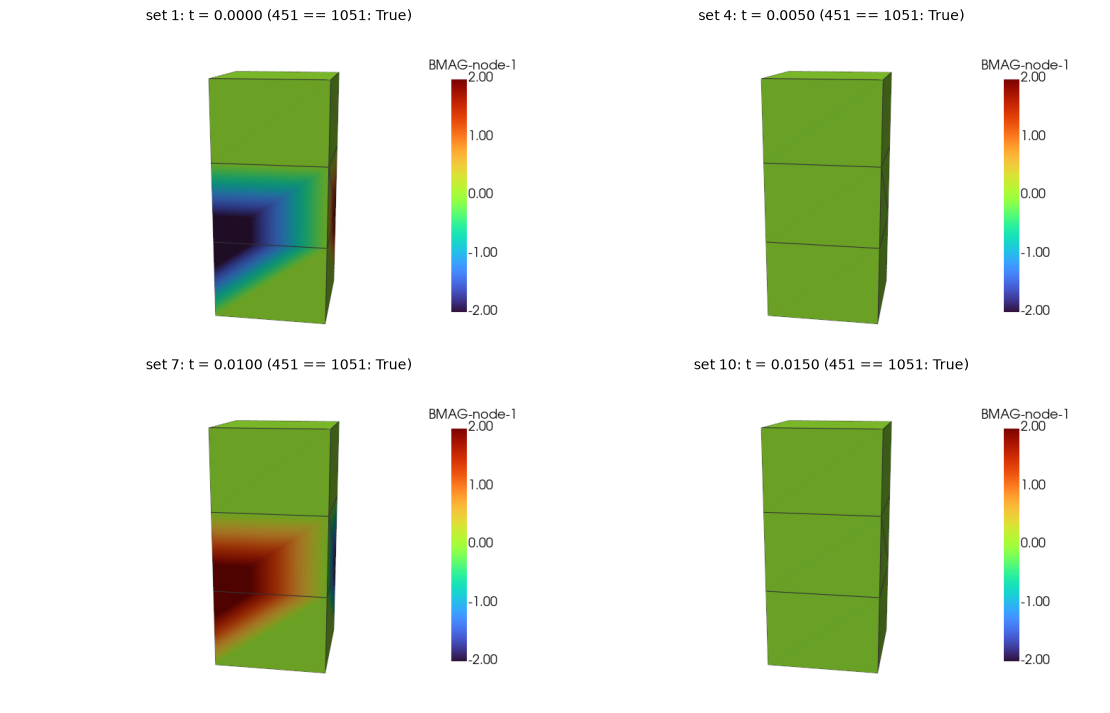

In [6]:
res = path('femap', 'ems_results_1051.neu')
times = mp.femap.time_values(res)
print('output set values:', np.round(times, 5))
items = []
for k in (0, 3, 6, 9):
    m = mp.read(res, time_step=k)
    same = np.array_equal(m.point_data['BMAG-node-1'],
                          mp.read(path('femap', 'ems_results_451.neu'), time_step=k).point_data['BMAG-node-1'])
    items.append((to_grid(m, point_data={'BMAG-node-1': m.point_data['BMAG-node-1']}), 'BMAG-node-1',
                  f'set {k + 1}: t = {times[k]:.4f} (451 == 1051: {same})', (-2, 2)))
gallery(items, ncols=2)

The same blocks from Femap 2020.1 (`1051` vectors, and seven lines after each output set's notes that older versions do not write) and from Femap 8.2 (`451`) hold the same Nastran run:

In [7]:
for name in ('v2020_results', 'v82_results'):
    m = mp.read(path('femap', f'{name}.neu'))
    t = m.point_data['T1 Translation']
    print(f'{name:14s} T1 Translation at the 12 nodes:', np.round(t, 4))

v2020_results  T1 Translation at the 12 nodes: [ 0.     -0.1871  0.      0.0701  0.      0.      0.     -0.0938  0.0356
  0.      0.      0.    ]
v82_results    T1 Translation at the 12 nodes: [ 0.     -0.1871  0.      0.0701  0.      0.      0.     -0.0938  0.0356
  0.      0.      0.    ]


## MFEM: an order-2 mesh and a field

`star-q2.mesh` is one of MFEM's own sample meshes: 20 quadrilaterals whose geometry is an order-2 `H1` grid function. meshio++ reads it to `quad9` cells whose points are MFEM's degrees of freedom, in MFEM's numbering: the vertices, then the edges in order of first appearance, then the element interiors. `star-q2.u.gf` is a field MFEM projected on it.

<meshio++ mesh object>
  Number of points: 101
  Number of cells:
    quad9: 20
    line3: 20
  Cell sets: attribute_1, boundary_1
  Point data: u
  Cell data: mfem:attribute


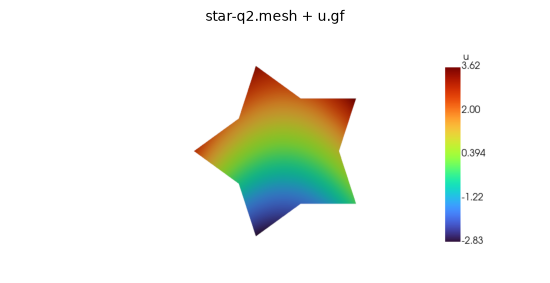

In [8]:
star = mp.mfem.read(path('mfem', 'star-q2.mesh'), {'u': path('mfem', 'star-q2.u.gf')})
print(star)
grid = to_grid(star, point_data={'u': star.point_data['u']})
gallery([(curved(grid), 'u', 'star-q2.mesh + u.gf', None)], ncols=1, size=(1000, 460), view=(0, 0, 1), edges=False)

`fichera-q2.mesh` has order-2 hexahedra, with a node on every edge, every face and in every cell; `fichera-q2.w.gf` a vector field stored interleaved (`Ordering: 1`). `escher-p2.mesh` is a solid of order-2 tetrahedra whose faces are visibly curved.

[('hexahedron27', 7), ('quad9', 24)] (117, 3)


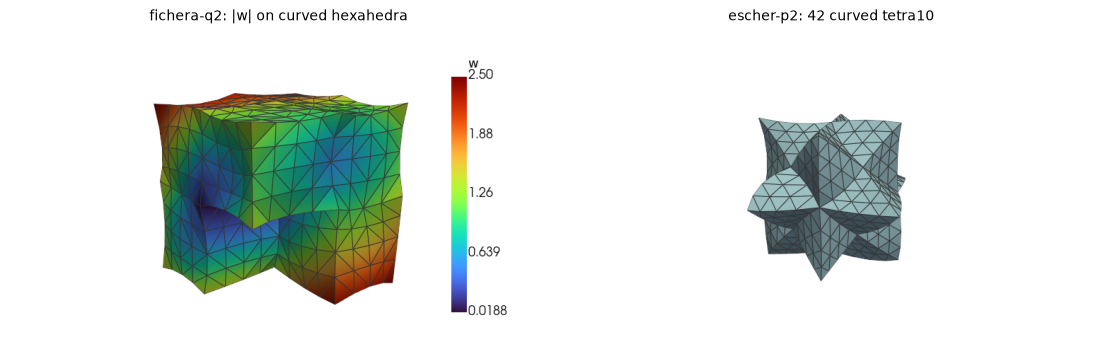

In [9]:
fichera = mp.mfem.read(path('mfem', 'fichera-q2.mesh'), {'w': path('mfem', 'fichera-q2.w.gf')})
print([(c.type, len(c.data)) for c in fichera.cells], fichera.point_data['w'].shape)
w = np.linalg.norm(fichera.point_data['w'], axis=1)
escher = mp.read(path('mfem', 'escher-p2.mesh'))
gallery([(curved(to_grid(fichera, point_data={'|w|': w}), 2), '|w|', 'fichera-q2: |w| on curved hexahedra', None),
         (curved(to_grid(escher), 2), None, f'escher-p2: {len(escher.cells[0].data)} curved tetra10', None)], ncols=2)

Writing goes the other way: a quadratic mesh becomes an `H1_<d>D_P2` nodes space, named cell regions become v1.3 attribute sets, and `grid_functions=True` writes every data array as a `.gf` beside the mesh. `.mesh` defaults to Medit when writing, so the MFEM writer is called by name; reading needs no hint, since a file whose first line names an MFEM mesh is read as one.

In [10]:
out = os.path.join(TMP, 'star.mesh')
mp.mfem.write(out, star, grid_functions=True)
print(sorted(f for f in os.listdir(TMP) if f.startswith('star')))
with open(out) as fh:
    text = fh.read().splitlines()
print('\n'.join(text[:3]))
start = text.index('nodes')
print('\n'.join(text[start:start + 6]))
back = mp.read(out)
print('points identical:', np.array_equal(back.points, star.points), '| cells:', [(c.type, len(c.data)) for c in back.cells])

['star.mesh', 'star.u.gf']
MFEM mesh v1.0
# Written by meshio++ v16.3.0

nodes
FiniteElementSpace
FiniteElementCollection: H1_2D_P2
VDim: 2
Ordering: 1

points identical: True | cells: [('quad9', 20), ('line3', 20)]


## What was checked

- **Patran:** no Patran, Cubit or ANSA was available. The reader follows the Patran 2 neutral file guide and the Element Library, and the fixtures are written from them; the two engines write the same bytes. A real Cubit export is still to be read (see the roadmap).
- **Femap:** no Femap was available either. The reader was checked against real files: 36 Femap 8.2 models from FrontISTR (every solid topology, mid-edge nodes on their edges), EMSolution's 4.41 results in both encodings, and Femap 2020.1, 8.2 and MYSTRAN result blocks, whose 2,770 values of the 8.2 and MYSTRAN files equal femap_neutral_parser's reading. Real Femap 9.1–11.0 exports (not redistributable) were read locally.
- **MFEM:** checked against MFEM 4.10 through PyMFEM in both directions. Every node meshio++ reads from 14 of MFEM's samples sits where MFEM's element transformation puts it, and MFEM reads the files meshio++ writes to the same geometry and field values. `tools/gen_mfem_fixtures.py` freezes MFEM's evaluation for the tests.

See the [Patran](../../doc/formats/patran.md), [Femap](../../doc/formats/femap.md) and [MFEM](../../doc/formats/mfem.md) pages.